# 1. Project Overview

This project analyzes real estate data in Mexico to understand the key factors affecting housing prices. The main objectives are:

1. Identify the most expensive states in Mexico
2. Analyze the relationship between property size and price
3. Explore how location influences real estate value

The dataset consists of three different sources that required cleaning, transformation, and consolidation before analysis.

---

# 1.1 Data Loading

In [34]:
import pandas as pd

In [35]:
df1 = pd.read_excel('data/mexico-real-estate-1.xlsx')
df2 = pd.read_excel('data/mexico-real-estate-2.xlsx')
df3 = pd.read_excel('data/mexico-real-estate-3.xlsx')

---



# 1.2 Data Cleaning


## 1.2.1 Handling Missing Values



All datasets contained missing values, especially in location-related columns. These rows were removed to ensure data quality.


In [36]:
df1.dropna(inplace=True)
df2.dropna(inplace=True)
df3.dropna(inplace=True)

---


## 1.2.2 Fixing Data Types and Currency



The second dataset stored prices in Mexican Peso. To standardize the data, prices were converted to USD.


In [37]:
df2["price_usd"] = (df2["price_mxn"] / 19).round(2)
df2.drop(columns=["price_mxn"], inplace=True)



---



## 1.2.3 Resolving Structural Issues



The third dataset required additional preprocessing:

1. Splitting latitude and longitude into separate columns
2. Extracting state information from hierarchical location data


In [38]:
df3[["lat", "lon"]] = df3["lat-lon"].str.split(",", expand=True)
df3["state"] = df3["place_with_parent_names"].str.split("|", expand=True)[2]

df3.drop(columns=["place_with_parent_names", "lat-lon"], inplace=True)



---



## 1.2.4 Merging Datasets



All cleaned datasets were combined into a single DataFrame.


In [39]:
df = pd.concat([df1, df2, df3])
df.to_csv('data/mexico-real-estate-clean.csv', index=False)



---



# 2. Exploratory Data Analysis (EDA)



## 2.1 Data Overview


In [40]:
df = pd.read_csv('data/mexico-real-estate-clean.csv')
df.head()


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150,67965.56
1,house,Nuevo León,25.688436,-100.198807,186,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150,94308.80
4,house,Yucatán,21.052583,-89.538639,205,105191.37



---



## 2.2 Geographical Distribution



To understand property locations, an interactive map was created.


In [41]:
import plotly.express as px

fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="lon",
    center={"lat": 19.43, "lon": -99.13},
    hover_data=["price_usd"],
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()


C:\Users\usfmg\AppData\Local\Temp\ipykernel_9212\1835029003.py:3: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(



The visualization shows that most properties are concentrated around major urban areas, especially Mexico City.



---



## 2.3 Categorical Analysis


In [42]:
df["state"].value_counts().head(10)
df["state"].nunique()
df["state"].unique()


<StringArray>
[               'Estado de México',                      'Nuevo León',
                        'Guerrero',                         'Yucatán',
                       'Querétaro',                         'Morelos',
                         'Chiapas',                         'Tabasco',
                'Distrito Federal',                         'Nayarit',
                          'Puebla', 'Veracruz de Ignacio de la Llave',
                         'Sinaloa',                      'Tamaulipas',
                         'Jalisco',                 'San Luis Potosí',
                 'Baja California',                         'Hidalgo',
                    'Quintana Roo',                          'Sonora',
                       'Chihuahua',             'Baja California Sur',
                       'Zacatecas',                  'Aguascalientes',
                      'Guanajuato',                         'Durango',
                        'Tlaxcala',                          'C


The dataset includes multiple states with varying representation. Some states appear more frequently, which may indicate sampling imbalance.



---



## 2.4 Numerical Analysis


In [43]:
df[["area_m2", "price_usd"]].describe()


,area_m2,price_usd
count,1736.000000,1736.000000
mean,170.261521,115331.980766
std,80.594539,65426.173873
min,60.000000,33157.890000
25%,101.750000,65789.470000
50%,156.000000,99262.130000
75%,220.000000,150846.665000
max,385.000000,326733.660000



Key observations:

1. The mean price is higher than the median, indicating a right-skewed distribution
2. The standard deviation is relatively high, showing large variability in prices
3. The dataset contains high-value outliers



---



## 2.5 Distribution Analysis



### 2.5.1 Area Distribution


Text(0.5, 1.0, 'Distribution of Property Area')

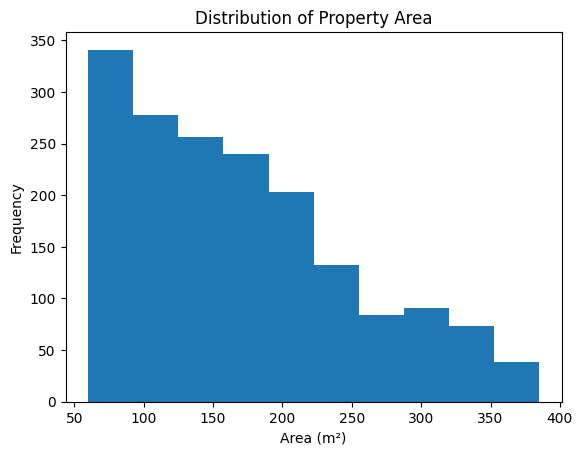

In [44]:
import matplotlib.pyplot as plt

plt.hist(df["area_m2"])
plt.xlabel("Area (m²)")
plt.ylabel("Frequency")
plt.title("Distribution of Property Area")



Most properties fall within the range of 50 to 200 square meters, indicating a concentration in mid-sized housing.



---



### 2.5.2 Price Distribution


Text(0.5, 1.0, 'Distribution of Property Prices')

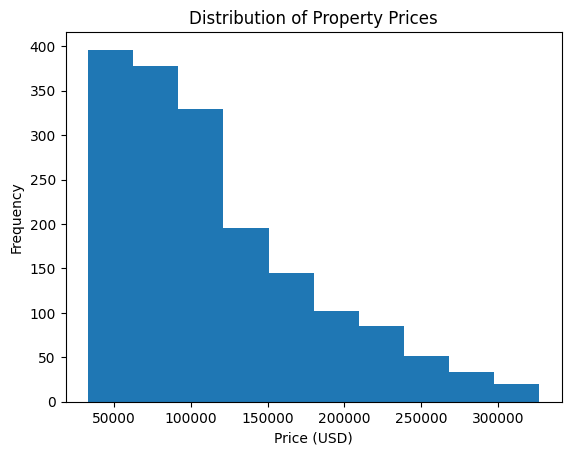

In [45]:
plt.hist(df["price_usd"])
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.title("Distribution of Property Prices")



Prices are highly skewed, with a small number of expensive properties significantly affecting the distribution.



---



# 3. Research Questions



---



## 3.1 Which State Has the Most Expensive Real Estate Market?



### 3.1.1 Mean Price by State


In [46]:
mean_price_by_state = df.groupby("state")["price_usd"].mean().sort_values(ascending=False)
mean_price_by_state.head()


state
Querétaro           133955.913281
Guanajuato          133277.965833
Nuevo León          129221.985663
Distrito Federal    128347.267426
Quintana Roo        128065.416053
Name: price_usd, dtype: float64


Using average price alone can be misleading due to differences in property sizes across states.



---



### 3.1.2 Price per Square Meter



To obtain a more accurate comparison, a new feature was created:


In [47]:
df["price_per_m2"] = df["price_usd"] / df["area_m2"]


In [48]:

df.groupby("state")["price_per_m2"].mean().sort_values(ascending=False)


state
Distrito Federal                   1175.889150
Estado de México                    763.753422
Guerrero                            761.557206
Jalisco                             743.568107
Quintana Roo                        736.455284
Nuevo León                          723.710040
Puebla                              700.701974
Querétaro                           687.227849
Oaxaca                              683.019737
Guanajuato                          672.908100
Baja California Sur                 662.401953
Morelos                             649.383992
Tabasco                             643.503348
Campeche                            601.291762
Nayarit                             599.293627
Baja California                     598.852988
Chihuahua                           591.226747
Chiapas                             560.317146
Sinaloa                             546.536310
Yucatán                             545.889476
Tamaulipas                          541.282076
Veracru


Conclusion:

1. Mexico City has the highest price per square meter
2. Price per square meter is a more reliable metric than total price
3. Economic activity and demand strongly influence pricing

---



## 3.2 Is There a Relationship Between Property Size and Price?



### 3.2.1 Scatter Plot


Text(0.5, 1.0, 'Price vs Area')

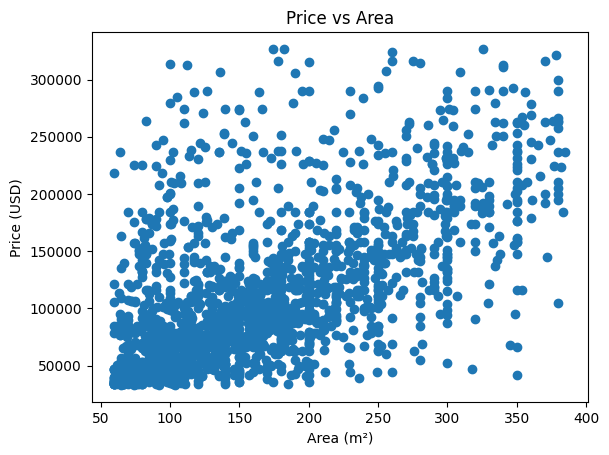

In [49]:
plt.scatter(df["area_m2"], df["price_usd"])
plt.xlabel("Area (m²)")
plt.ylabel("Price (USD)")
plt.title("Price vs Area")



The plot indicates a positive relationship between size and price.

---



### 3.2.2 Correlation Analysis


In [50]:
df["area_m2"].corr(df["price_usd"])


np.float64(0.585518245323206)


The correlation coefficient is approximately 0.58, indicating a moderate relationship.

---



### 3.2.3 Case Study: Morelos


In [51]:
df_morelos = df[df["state"] == "Morelos"]
df_morelos["area_m2"].corr(df_morelos["price_usd"])


np.float64(0.8498077608713712)


In Morelos, the correlation is significantly stronger, suggesting that size plays a major role in pricing.

---



### 3.2.4 Case Study: Mexico City


In [52]:
df_mexico_city = df[df["state"] == "Distrito Federal"]
df_mexico_city["area_m2"].corr(df_mexico_city["price_usd"])


np.float64(0.41070392130717864)


In Mexico City, the relationship is weaker, indicating that other factors such as location, demand, and economic conditions have a greater influence on price.

---



# 4. Final Conclusions



1. Location is the most influential factor in determining property prices
2. Property size has a moderate impact overall
3. In major cities, price is influenced by multiple complex factors beyond size
4. Price per square meter is a more accurate metric for comparison than total price

---
